# 통합 데이터 모델 — Baseline 대비 LOOCV 전진선택

화요일 단독 모델(`03_tuesday_solo_model.ipynb`)에서 소표본 과적합을 확인했으므로, 요일별 분리를 접고 전체 통합 데이터로 다시 모델링한다. 판단 기준은 "이 피처를 넣은 모델이, 피처 없이 타겟 평균만 찍는 모델 (baseline)보다 나은가?"이며, 검증은 LOOCV RMSE로 한다.


## 설정 및 데이터 준비


In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

import subprocess
import matplotlib.font_manager as fm

subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print('폰트 적용:', plt.rcParams['font.family'])


import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print("✅ 라이브러리 로드 완료")


폰트 적용: ['NanumGothic']
✅ 라이브러리 로드 완료


In [2]:
data = pd.read_csv('/content/ols_model_feature_0506.csv')
data.head()


,dcl_id,date,day_of_week,before_rest,cumul_16_19,cumul_20_22,lag_prev_day_t1,lag_prev_day_t2,lag_same_day_t1,lag_same_day_t2,lag_biweekly_t1,lag_biweekly_t2,roll_prev_3days_mean_t1,roll_prev_3days_mean_t2,roll_same_3days_mean_t1,roll_same_3days_mean_t2,roll_prev_5days_mean_t1,roll_prev_5days_mean_t2
0,dcl_0511,2026-05-11,월,0,11550,9100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,dcl_0512,2026-05-12,화,0,16600,11700,11550.0,9100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,dcl_0515,2026-05-15,금,1,12300,11150,16600.0,11700.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,dcl_0518,2026-05-18,월,0,12600,16900,12300.0,11150.0,11550.0,9100.0,NaN,NaN,13483.33,10650.0,NaN,NaN,NaN,NaN
4,dcl_0519,2026-05-19,화,0,9200,6950,12600.0,16900.0,16600.0,11700.0,NaN,NaN,13833.33,13250.0,NaN,NaN,NaN,NaN


In [3]:
data.info()
data['date']=pd.to_datetime(data['date'])
data['before_rest']=pd.to_numeric(data['before_rest'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   dcl_id                   23 non-null     object 
 1   date                     23 non-null     object 
 2   day_of_week              23 non-null     object 
 3   before_rest              23 non-null     int64  
 4   cumul_16_19              23 non-null     int64  
 5   cumul_20_22              23 non-null     int64  
 6   lag_prev_day_t1          22 non-null     float64
 7   lag_prev_day_t2          22 non-null     float64
 8   lag_same_day_t1          20 non-null     float64
 9   lag_same_day_t2          20 non-null     float64
 10  lag_biweekly_t1          17 non-null     float64
 11  lag_biweekly_t2          17 non-null     float64
 12  roll_prev_3days_mean_t1  20 non-null     float64
 13  roll_prev_3days_mean_t2  20 non-null     float64
 14  roll_same_3days_mean_t1  14 

In [4]:
data.describe()

,date,before_rest,cumul_16_19,cumul_20_22,lag_prev_day_t1,lag_prev_day_t2,lag_same_day_t1,lag_same_day_t2,lag_biweekly_t1,lag_biweekly_t2,roll_prev_3days_mean_t1,roll_prev_3days_mean_t2,roll_same_3days_mean_t1,roll_same_3days_mean_t2,roll_prev_5days_mean_t1,roll_prev_5days_mean_t2
count,23,23.000000,23.000000,23.000000,22.000000,22.000000,20.000000,20.00000,17.000000,17.000000,20.000000,20.000000,14.000000,14.000000,18.000000,18.000000
mean,2026-06-05 00:00:00,0.347826,10450.000000,8230.434783,10329.545455,8209.090909,10805.000000,8342.50000,10882.352941,8426.470588,10457.499500,8236.667500,10815.475000,7966.666429,10433.333333,8011.666667
min,2026-05-11 00:00:00,0.000000,3450.000000,3400.000000,3450.000000,3400.000000,5200.000000,3400.00000,5200.000000,3400.000000,6283.330000,6100.000000,9483.330000,4766.670000,8360.000000,5920.000000
25%,2026-05-23 12:00:00,0.000000,8550.000000,5550.000000,8350.000000,5450.000000,9137.500000,5650.00000,9200.000000,5350.000000,9712.497500,6587.500000,9737.502500,6033.330000,9212.500000,7222.500000
50%,2026-06-05 00:00:00,0.000000,10850.000000,7500.000000,10675.000000,7375.000000,10925.000000,7375.00000,11000.000000,7250.000000,10783.335000,7675.000000,10791.665000,7408.335000,10825.000000,7585.000000
75%,2026-06-17 12:00:00,1.000000,12450.000000,10475.000000,12250.000000,10637.500000,12375.000000,10887.50000,12600.000000,11150.000000,11387.502500,8700.002500,11574.997500,9725.000000,11290.000000,8510.000000
max,2026-06-30 00:00:00,1.000000,16600.000000,16900.000000,16600.000000,16900.000000,16600.000000,16900.00000,16600.000000,16900.000000,13833.330000,13250.000000,12500.000000,12300.000000,12450.000000,11760.000000
std,NaN,0.486985,3121.698256,3451.703767,3139.974943,3531.377593,2793.644102,3560.42853,2952.273551,3794.202718,1978.491899,2096.345839,1129.848954,2462.027736,1305.945679,1600.456736


## 요일 더미 변수 생성


In [5]:
day_order = pd.CategoricalDtype(categories=['월', '화', '금'], ordered=False)
data['day_of_week'] = data['day_of_week'].astype(day_order)

day_dummies = pd.get_dummies(data['day_of_week'], drop_first=True, dtype=int)  # 월요일 기준(baseline)
data = pd.concat([data, day_dummies], axis=1)
data.columns


Index(['dcl_id', 'date', 'day_of_week', 'before_rest', 'cumul_16_19',
       'cumul_20_22', 'lag_prev_day_t1', 'lag_prev_day_t2', 'lag_same_day_t1',
       'lag_same_day_t2', 'lag_biweekly_t1', 'lag_biweekly_t2',
       'roll_prev_3days_mean_t1', 'roll_prev_3days_mean_t2',
       'roll_same_3days_mean_t1', 'roll_same_3days_mean_t2',
       'roll_prev_5days_mean_t1', 'roll_prev_5days_mean_t2', '화', '금'],
      dtype='object')

## 피처 상관관계 히트맵


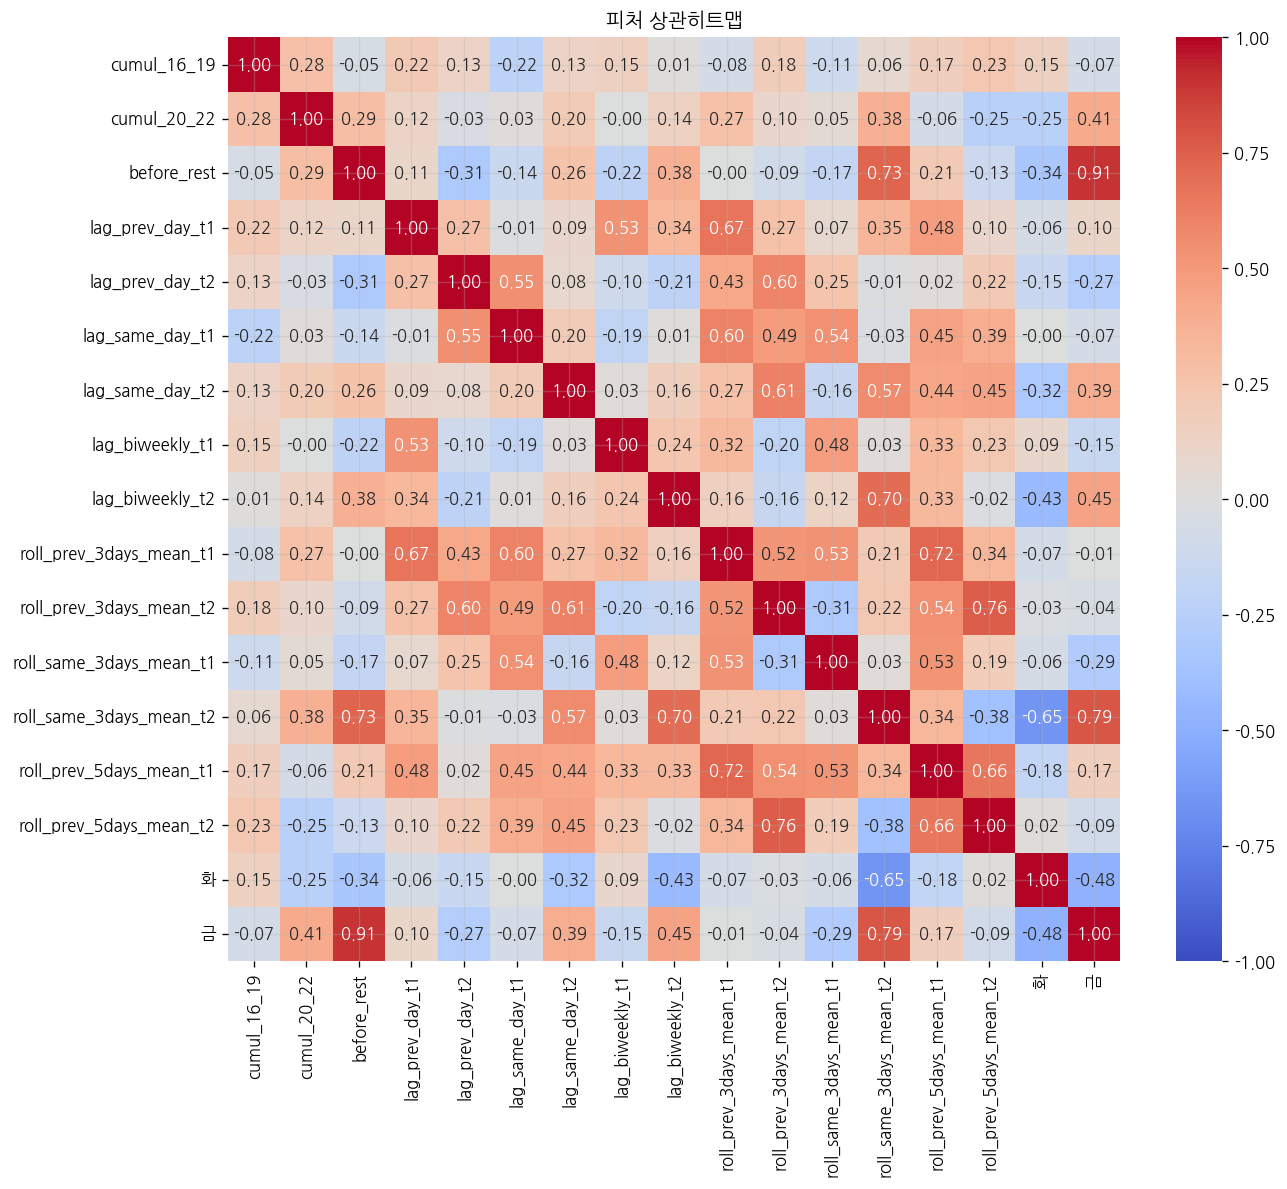

In [6]:
corr_col=[ 'cumul_16_19', 'cumul_20_22','before_rest',
       'lag_prev_day_t1', 'lag_prev_day_t2', 'lag_same_day_t1',
       'lag_same_day_t2', 'lag_biweekly_t1', 'lag_biweekly_t2',
       'roll_prev_3days_mean_t1', 'roll_prev_3days_mean_t2',
       'roll_same_3days_mean_t1', 'roll_same_3days_mean_t2',
       'roll_prev_5days_mean_t1', 'roll_prev_5days_mean_t2', '화', '금']

corr_matrix=data[corr_col].corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title("피처 상관히트맵")
plt.show()

---
## LOOCV 기반 전진선택 — 함수 정의

- `loocv_rmse`: 주어진 피처 조합 하나의 LOOCV RMSE를 계산
- `forward_selection`: baseline(피처 없음)부터 시작해, RMSE를 유의미하게(`margin` 이상) 낮추는 피처만 하나씩 채택. T1·T2 양쪽에 동일하게 적용한다.


In [7]:
def loocv_rmse(X, y):
    """
    X: 피처 데이터프레임 (여러 컬럼)
    y: 타겟 시리즈 (cumul_16_19 또는 cumul_20_22)

    - 전체 n개 행 중 1개를 test로 빼고, 나머지 n-1개로 모델 학습
    - 그 1개를 예측 → 실제값과 비교해서 기록
    - 이 과정을 n번(모든 행에 대해 한 번씩) 반복
    - n개의 (예측값, 실제값) 쌍이 다 모이면 RMSE 계산
    """
    loo = LeaveOneOut()
    y_true_list, y_pred_list = [], []

    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        y_true_list.append(y_test.values[0])
        y_pred_list.append(y_pred[0])

    return np.sqrt(mean_squared_error(y_true_list, y_pred_list))


def forward_selection(df, target, base_features, candidate_features,
                       max_features=5, margin=0.0, verbose=True):
    """
    base_features: 무조건 포함할 피처 (이번엔 빈 리스트 → 강제 고정 없음)
    candidate_features: 검증 대상 후보 전체 (요일 더미 포함)
    max_features: 최종 최대 피처 개수 (과적합 방지)
    margin: 이 정도는 개선돼야 "진짜 개선"으로 인정할 RMSE 최소 감소폭
    """
    y = df[target]
    selected = base_features.copy()
    remaining = candidate_features.copy()

    if len(selected) == 0:
        X_start = pd.DataFrame({'const': np.ones(len(df))})
        current_rmse = loocv_rmse(X_start, y)
    else:
        current_rmse = loocv_rmse(df[selected], y)

    if verbose:
        print(f"[시작] baseline={selected if selected else '(피처 없음, 평균값만으로 잔차확인)'} → RMSE={current_rmse:.2f}\n")

    while remaining and len(selected) < max_features:
        best_candidate, best_rmse = None, current_rmse

        for feat in remaining:
            trial_rmse = loocv_rmse(df[selected + [feat]], y)
            if verbose:
                print(f"  시도: {selected} + [{feat}] → RMSE={trial_rmse:.2f}")
            if trial_rmse < best_rmse - margin:
                best_rmse, best_candidate = trial_rmse, feat

        if best_candidate is None:
            if verbose:
                print("\n→ 더 이상 개선되는 피처 없음. 선택 종료\n")
            break

        selected.append(best_candidate)
        remaining.remove(best_candidate)
        current_rmse = best_rmse
        if verbose:
            print(f"[채택] '{best_candidate}' 추가 → RMSE={current_rmse:.2f}\n")

    return selected, current_rmse


---
## T1 — cumul_16_19 전진선택


In [8]:
# 요일 더미(화,금)도 이제 "강제 포함"이 아니라 검증받아야 할 후보
# roll_same_3days_mean_t1은 결측이 제일 심해서(n=14 수준) 일단 후보에서 제외
candidates_t1 = [
    'before_rest', 'lag_prev_day_t1', 'lag_prev_day_t2', 'lag_same_day_t1', 'lag_same_day_t2',
    'lag_biweekly_t1', 'lag_biweekly_t2',
    'roll_prev_3days_mean_t1', 'roll_prev_3days_mean_t2',
    'roll_prev_5days_mean_t1', 'roll_prev_5days_mean_t2', '화', '금',
]

common_cols_t1 = candidates_t1 + ['cumul_16_19']
df_common_t1 = data.dropna(subset=common_cols_t1).reset_index(drop=True)

print(f"모델 내 공통 표본 크기: {len(df_common_t1)}행")
print(f"모델 타겟의 표준편차: {df_common_t1['cumul_16_19'].std():.2f}\n")

selected_t1, rmse_t1 = forward_selection(
    df=df_common_t1, target='cumul_16_19',
    base_features=[], candidate_features=candidates_t1,
    max_features=3, margin=50,
)

print("=" * 50)
print(f"[T1 최종 선택 피처] {selected_t1}")
print(f"[T1 최종 RMSE] {rmse_t1:.2f}")
print(f"[비교 기준] std = {df_common_t1['cumul_16_19'].std():.2f}")


모델 내 공통 표본 크기: 17행
모델 타겟의 표준편차: 3162.48

[시작] baseline=(피처 없음, 평균값만으로 잔차확인) → RMSE=3259.81

  시도: [] + [before_rest] → RMSE=3426.76
  시도: [] + [lag_prev_day_t1] → RMSE=3570.03
  시도: [] + [lag_prev_day_t2] → RMSE=3468.02
  시도: [] + [lag_same_day_t1] → RMSE=3261.10
  시도: [] + [lag_same_day_t2] → RMSE=3483.11
  시도: [] + [lag_biweekly_t1] → RMSE=3563.74
  시도: [] + [lag_biweekly_t2] → RMSE=3405.34
  시도: [] + [roll_prev_3days_mean_t1] → RMSE=3372.51
  시도: [] + [roll_prev_3days_mean_t2] → RMSE=3380.34
  시도: [] + [roll_prev_5days_mean_t1] → RMSE=3437.46
  시도: [] + [roll_prev_5days_mean_t2] → RMSE=3272.75
  시도: [] + [화] → RMSE=3427.73
  시도: [] + [금] → RMSE=3422.93

→ 더 이상 개선되는 피처 없음. 선택 종료

[T1 최종 선택 피처] []
[T1 최종 RMSE] 3259.81
[비교 기준] std = 3162.48


→ baseline(RMSE=3259.81)을 유의미하게 넘어서는 피처가 하나도 없어, T1은 **baseline 그대로 채택**된다 (표본 n=17에 아직 예측 신호가 축적되지 않은 상태 — 이상치 민감도 검증은 `06_outlier_leverage_analysis.ipynb` 참고).


---
## T2 — cumul_20_22 전진선택


In [9]:
candidates_t2 = [
    'cumul_16_19', 'before_rest', 'lag_prev_day_t1', 'lag_prev_day_t2', 'lag_same_day_t1', 'lag_same_day_t2',
    'lag_biweekly_t1', 'lag_biweekly_t2',
    'roll_prev_3days_mean_t1', 'roll_prev_3days_mean_t2',
    'roll_prev_5days_mean_t1', 'roll_prev_5days_mean_t2', '화', '금',
    # roll_same_3days_mean_t2도 결측 심하니 일단 제외하고 시작 권장
]

common_cols_t2 = candidates_t2 + ['cumul_20_22']
df_common_t2 = data.dropna(subset=common_cols_t2).reset_index(drop=True)

print(f"공통 표본 크기: {len(df_common_t2)}행")
print(f"타겟 표준편차: {df_common_t2['cumul_20_22'].std():.2f}")

selected_t2, rmse_t2 = forward_selection(
    df=df_common_t2, target='cumul_20_22',
    base_features=[], candidate_features=candidates_t2,
    max_features=3, margin=50,
)
print(f"[T2 최종] {selected_t2}, RMSE={rmse_t2:.2f}")
print(f"[비교] std={df_common_t2['cumul_20_22'].std():.2f}")


공통 표본 크기: 17행
타겟 표준편차: 2837.82
[시작] baseline=(피처 없음, 평균값만으로 잔차확인) → RMSE=2925.15

  시도: [] + [cumul_16_19] → RMSE=3084.97
  시도: [] + [before_rest] → RMSE=2807.32
  시도: [] + [lag_prev_day_t1] → RMSE=2991.23
  시도: [] + [lag_prev_day_t2] → RMSE=2991.28
  시도: [] + [lag_same_day_t1] → RMSE=3054.38
  시도: [] + [lag_same_day_t2] → RMSE=3402.63
  시도: [] + [lag_biweekly_t1] → RMSE=3140.50
  시도: [] + [lag_biweekly_t2] → RMSE=3048.89
  시도: [] + [roll_prev_3days_mean_t1] → RMSE=3021.87
  시도: [] + [roll_prev_3days_mean_t2] → RMSE=2754.10
  시도: [] + [roll_prev_5days_mean_t1] → RMSE=2976.12
  시도: [] + [roll_prev_5days_mean_t2] → RMSE=2590.24
  시도: [] + [화] → RMSE=3024.90
  시도: [] + [금] → RMSE=2482.72
[채택] '금' 추가 → RMSE=2482.72

  시도: ['금'] + [cumul_16_19] → RMSE=2605.51
  시도: ['금'] + [before_rest] → RMSE=2604.42
  시도: ['금'] + [lag_prev_day_t1] → RMSE=2589.87
  시도: ['금'] + [lag_prev_day_t2] → RMSE=2624.62
  시도: ['금'] + [lag_same_day_t1] → RMSE=2647.78
  시도: ['금'] + [lag_same_day_t2] → RMSE=2738.46
  시도

## T2 최종 계수 (sklearn, 참고용)


In [10]:
final_model_t2_sk = LinearRegression()
final_model_t2_sk.fit(df_common_t2[selected_t2], df_common_t2['cumul_20_22'])

print("절편:", final_model_t2_sk.intercept_)
print("계수:", dict(zip(selected_t2, final_model_t2_sk.coef_)))


절편: 11022.94511352007
계수: {'금': np.float64(3615.4752411677264), 'roll_prev_3days_mean_t2': np.float64(-0.6508446538664603)}


## 요일 더미로 인한 스케일 차이 — 표준화로 상대적 영향력 확인

`금`(0/1)과 `roll_prev_3days_mean_t2`(수천 단위)의 스케일 차이가 조건수(다중공선성 경고)를 유발하는지 확인하기 위해, 연속형 변수만 표준화한 뒤 재적합한다.


In [11]:
X_std = df_common_t2[selected_t2].copy()
continuous_vars = ['roll_prev_3days_mean_t2']  # 연속형만 표준화, '금'은 0/1 유지
scaler = StandardScaler()
X_std[continuous_vars] = scaler.fit_transform(X_std[continuous_vars])
X_std = sm.add_constant(X_std)

model_std_t2 = sm.OLS(df_common_t2['cumul_20_22'], X_std).fit()
print(model_std_t2.summary())


                            OLS Regression Results                            
Dep. Variable:            cumul_20_22   R-squared:                       0.505
Model:                            OLS   Adj. R-squared:                  0.434
Method:                 Least Squares   F-statistic:                     7.138
Date:                Tue, 14 Jul 2026   Prob (F-statistic):            0.00730
Time:                        05:14:19   Log-Likelihood:                -152.80
No. Observations:                  17   AIC:                             311.6
Df Residuals:                      14   BIC:                             314.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    6

## T2 최종 모델 — 실제 스케일 회귀계수 (statsmodels)


In [12]:
X_t2 = sm.add_constant(df_common_t2[selected_t2])
y_t2 = df_common_t2['cumul_20_22']
final_model_t2 = sm.OLS(y_t2, X_t2).fit()
print(final_model_t2.summary())


                            OLS Regression Results                            
Dep. Variable:            cumul_20_22   R-squared:                       0.505
Model:                            OLS   Adj. R-squared:                  0.434
Method:                 Least Squares   F-statistic:                     7.138
Date:                Tue, 14 Jul 2026   Prob (F-statistic):            0.00730
Time:                        05:14:19   Log-Likelihood:                -152.80
No. Observations:                  17   AIC:                             311.6
Df Residuals:                      14   BIC:                             314.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    1

## 모델 저장 (재사용을 위한 직렬화)


In [13]:
final_model_t2.save('model_t2.pickle')

loaded_model = sm.load('model_t2.pickle')
print(loaded_model.summary())


                            OLS Regression Results                            
Dep. Variable:            cumul_20_22   R-squared:                       0.505
Model:                            OLS   Adj. R-squared:                  0.434
Method:                 Least Squares   F-statistic:                     7.138
Date:                Tue, 14 Jul 2026   Prob (F-statistic):            0.00730
Time:                        05:14:19   Log-Likelihood:                -152.80
No. Observations:                  17   AIC:                             311.6
Df Residuals:                      14   BIC:                             314.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    1

---
## 종합

| | T1 (cumul_16_19) | T2 (cumul_20_22) |
|---|---|---|
| Baseline RMSE | 3259.81 | 2925.15 |
| 채택된 피처 | 없음 (0개) | `금`, `roll_prev_3days_mean_t2` |
| 최종 RMSE | 3259.81 (baseline 그대로) | 2333.35 (약 20% 개선) |
| 전체 모델 유의성 | — | F=7.138, p=0.0073 (유의) |

T2는 `금`(+3,615g, p=0.007)과 `roll_prev_3days_mean_t2`(p=0.099, 경계선)로 baseline을 실질적으로 넘어서는 예측 신호가 확인된 유일한 케이스다. T1은 baseline을 넘는 신호가 없어 표본 확대 후 재검증이 필요하다.

**다음 단계**: 이 T2 모델(`final_model_t2`)을 실제로 한 번도 학습에 쓰지 않은 새 날짜에 적용해, 사장님의 감각 기반 예측(A) 및 단순 일평균(C)과 비교하는 **사후 시뮬레이션**으로 넘어간다 (`05_posthoc_simulation.ipynb`에서 계속).
